# 🧠 Perceptron Trick — Cheat Sheet

## 1. What It Is
A rule for training a **linear classifier** by nudging the decision line every time it makes a mistake — no calculus, just geometry.

## 2. The Model
$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$
$$\hat{y} = \begin{cases}1 & z \geq 0\\0 & z < 0\end{cases}$$

## 3. The Two Mistake Cases

| Situation | Condition | Fix |
|---|---|---|
| Negative point predicted positive | $x_i \in N$ and $\sum w_ix_i \geq 0$ | $w_n = w_o - \eta x_i$ |
| Positive point predicted negative | $x_i \in P$ and $\sum w_ix_i < 0$ | $w_n = w_o + \eta x_i$ |

## 4. The Unified Formula (the "trick")
$$w_n = w_o + \eta\,(y_i - \hat{y}_i)\,x_i$$

## 5. Truth Table — Why It Works
| $y_i$ | $\hat{y}_i$ | $y_i-\hat{y}_i$ | Action |
|---|---|---|---|
| 1 | 1 | 0 | No change |
| 0 | 0 | 0 | No change |
| 1 | 0 | +1 | Add point (pull line toward it) |
| 0 | 1 | -1 | Subtract point (push line away) |

## 6. Training Loop
```
for i in range(epochs):
    pick a random data point
    predict ŷ
    update: w = w + η(y - ŷ) * x
```

## 7. Convergence Rule
✅ Guaranteed to converge **only if data is linearly separable**.
❌ Loops forever on non-separable data (e.g. XOR).

## 8. Transformation Trick (non-linear data)
If a straight line can't separate the data (e.g. points in a circle), **transform the features** first:
$$(x_1, x_2) \rightarrow (x_1^2 + x_2^2)$$
Now a simple threshold ("> radius?") separates the classes — linear again in the new space.

## 9. Minimal Python
```python
import numpy as np

## 10. Quick Comparison
| | Perceptron Trick | Gradient Descent |
|---|---|---|
| Updates on | Misclassified points only | Every point |
| Output | Hard label (0/1) | Probability |
| Converges if | Linearly separable | Always (to a minimum) |

## 11. Key Terms
- **η (eta)** — learning rate, controls step size
- **Epoch** — one full pass (or N random picks) through training
- **Bias trick** — insert $x_0=1$ so bias updates like a weight
- **Linearly separable** — a straight line/hyperplane can fully split the classes

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [42]:
X,y=make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42,
    hypercube=False,
    class_sep=4,
    flip_y=0

)

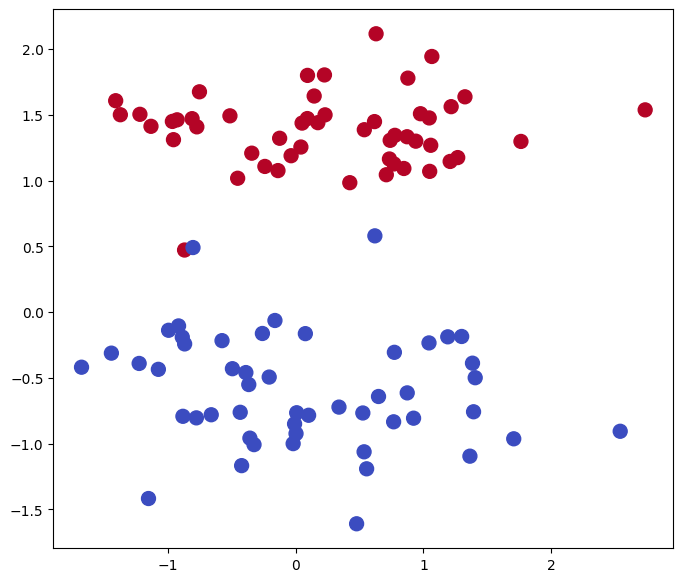

In [24]:
plt.figure(figsize=(8,7))
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',s=100)

In [43]:
def perceptron(X, y, epochs=100, lr=0.01):
    X_with_bias = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X_with_bias.shape[1])

    for _ in range(epochs):
        errors = 0
        for sample, target in zip(X_with_bias, y):
            prediction = step_function(np.dot(sample, weights))
            update = lr * (target - prediction)
            weights += update * sample
            errors += update != 0
        if errors == 0:
            break

    return weights[0], weights[1:]

In [26]:
np.dot(np.insert(X[41],0,1),[1,1,1,])

np.float64(0.14285232783504853)

In [27]:
def step_function(t):
    if t>=0:
        return 1
    return 0

In [28]:
step_function(-0.142)

0

In [44]:
intercept_,coeff_=perceptron(X,y)
print(intercept_)
print(coeff_)

-0.12000000000000073
[0.11528822 1.41703511]


In [46]:
m=-coeff_[0]/coeff_[1]
c=-intercept_/coeff_[1]

In [47]:
X_input=np.linspace(-3,3,100)
y_input=m*X_input+c

(-3.0, 3.0)

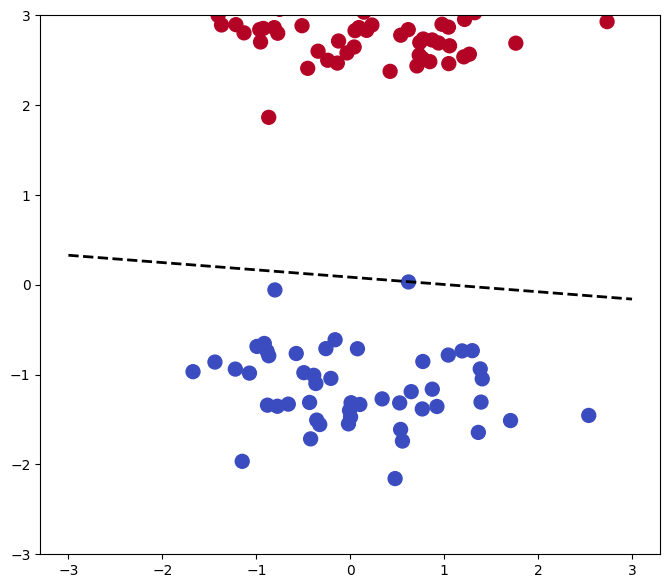

In [48]:
plt.figure(figsize=(8,7))
plt.plot(X_input,y_input,'k--',label='Decision Boundary',linewidth=2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',s=100)
plt.ylim(-3,3)

In [45]:
X_with_bias = np.insert(X, 0, 1, axis=1)
predictions = np.array([
    step_function(np.dot(sample, np.r_[intercept_, coeff_]))
    for sample in X_with_bias
])
print(f"Training accuracy: {(predictions == y).mean():.0%}")

Training accuracy: 100%
